In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

### Alanyzing Data_full

In [198]:
with open("F:/MyProjects/Zero-shot-Dynamic-Routing-System/data/data_full.json") as f:
    data_full = json.load(f)

In [199]:
data_full

{'oos_val': [['set a warning for when my bank account starts running low',
   'oos'],
  ['a show on broadway', 'oos'],
  ['who has the best record in the nfl', 'oos'],
  ['how do i find the area of a circle', 'oos'],
  ['how many onions do i have on hand', 'oos'],
  ['what is the name of the 13th president', 'oos'],
  ['show me recent activity in my backyard', 'oos'],
  ['how long will it take me to pay off my card if i pay an extra $50 a month over the minimum',
   'oos'],
  ['does our bank have free notary', 'oos'],
  ['what were the top stories this week', 'oos'],
  ['can i mix antifreeze with water', 'oos'],
  ['are any earning reports due', 'oos'],
  ['show me the channel guide', 'oos'],
  ['is the pnc bank open', 'oos'],
  ['where does the power steering fluid go', 'oos'],
  ['when was the last time the president visited floridau', 'oos'],
  ['how can i keep my windshield from fogging up in winter', 'oos'],
  ['how do i compute the median of a set of numbers', 'oos'],
  ['what is

In [200]:
df_train = pd.DataFrame(data_full['train'], columns=['utterance', 'intent'])
df_test = pd.DataFrame(data_full['test'], columns=['utterance', 'intent'])
df_val = pd.DataFrame(data_full['val'], columns=['utterance', 'intent'])
df_oos = pd.DataFrame(data_full['oos_val'], columns=['utterance', 'intent'])

In [201]:
df1 = pd.concat([df_train,df_test,df_val, df_oos], ignore_index=True)

In [202]:
display(df1.shape)
df1.head()

(22600, 2)

,utterance,intent
0,what expression would i use to say i love you ...,translate
1,can you tell me how to say 'i do not speak muc...,translate
2,"what is the equivalent of, 'life is good' in f...",translate
3,"tell me how to say, 'it is a beautiful morning...",translate
4,"if i were mongolian, how would i say that i am...",translate


In [203]:
print(f"Total In-Scope training Samples: {len(df_train)}")
print(f"Total In-Scope test Samples: {len(df_test)}")
print(f"Total In-Scope Validation Samples: {len(df_val)}")
print(f"Total Out-of-Scope Validation Samples: {len(df_oos)}")
print(f"Total Combined Samples: {len(df1)}")
print(f"Number of Unique In-Scope Intents: {df_train['intent'].nunique()}\n")

Total In-Scope training Samples: 15000
Total In-Scope test Samples: 4500
Total In-Scope Validation Samples: 3000
Total Out-of-Scope Validation Samples: 100
Total Combined Samples: 22600
Number of Unique In-Scope Intents: 150



In [204]:

print(df_train['intent'].value_counts().head(10))

intent
translate               100
transfer                100
timer                   100
definition              100
meaning_of_life         100
insurance_change        100
find_phone              100
travel_alert            100
pto_request             100
improve_credit_score    100
Name: count, dtype: int64


In [173]:
df1['word_count'] = df1['utterance'].apply(lambda x: len(x.split()))

In [174]:
print(df1['word_count'].describe())

count    22600.000000
mean         8.301858
std          3.234652
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         28.000000
Name: word_count, dtype: float64


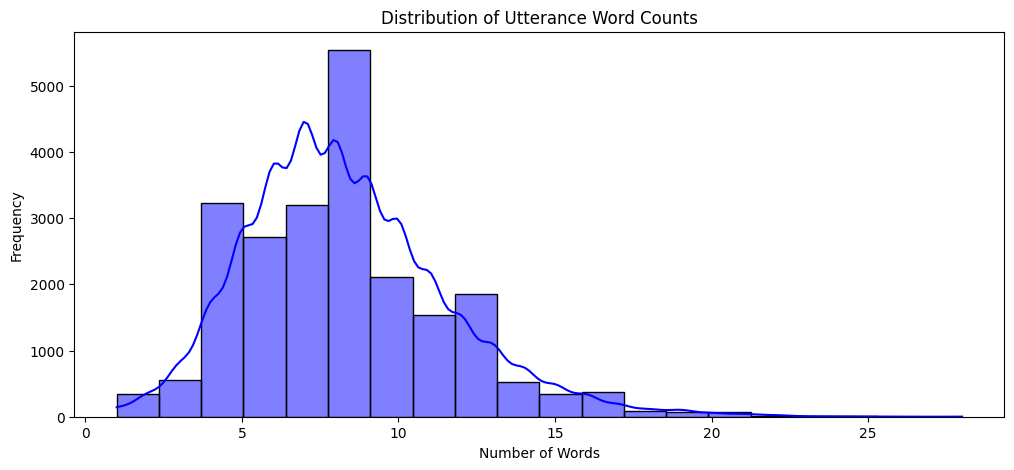

In [175]:
plt.figure(figsize=(12, 5))
sns.histplot(df1['word_count'], bins=20, kde=True, color='blue')
plt.title('Distribution of Utterance Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

## Analyzing data_imbalanced

In [176]:
with open("F:/MyProjects/Zero-shot-Dynamic-Routing-System/data/data_imbalanced.json") as f:
    data_imb = json.load(f)

In [177]:
data_imb

{'oos_val': [['set a warning for when my bank account starts running low',
   'oos'],
  ['a show on broadway', 'oos'],
  ['who has the best record in the nfl', 'oos'],
  ['how do i find the area of a circle', 'oos'],
  ['how many onions do i have on hand', 'oos'],
  ['what is the name of the 13th president', 'oos'],
  ['show me recent activity in my backyard', 'oos'],
  ['how long will it take me to pay off my card if i pay an extra $50 a month over the minimum',
   'oos'],
  ['does our bank have free notary', 'oos'],
  ['what were the top stories this week', 'oos'],
  ['can i mix antifreeze with water', 'oos'],
  ['are any earning reports due', 'oos'],
  ['show me the channel guide', 'oos'],
  ['is the pnc bank open', 'oos'],
  ['where does the power steering fluid go', 'oos'],
  ['when was the last time the president visited floridau', 'oos'],
  ['how can i keep my windshield from fogging up in winter', 'oos'],
  ['how do i compute the median of a set of numbers', 'oos'],
  ['what is

In [178]:
df_train = pd.DataFrame(data_imb['train'], columns=['utterance', 'intent'])
df_test = pd.DataFrame(data_imb['test'], columns=['utterance', 'intent'])
df_val = pd.DataFrame(data_imb['val'], columns=['utterance', 'intent'])
df_oos = pd.DataFrame(data_imb['oos_val'], columns=['utterance', 'intent'])

In [179]:
df2 = pd.concat([df_train,df_test,df_val, df_oos], ignore_index=True)

In [180]:
display(df2.shape)
df2.head()

(18125, 2)

,utterance,intent
0,what are the steps for setting up direct depos...,direct_deposit
1,how is a direct deposit set up,direct_deposit
2,how would i go about setting up a direct deposit,direct_deposit
3,tell me how to set up a direct deposit,direct_deposit
4,how do i arrange a direct deposit into my savi...,direct_deposit


In [181]:
print(f"Total In-Scope training Samples: {len(df_train)}")
print(f"Total In-Scope test Samples: {len(df_test)}")
print(f"Total In-Scope Validation Samples: {len(df_val)}")
print(f"Total Out-of-Scope Validation Samples: {len(df_oos)}")
print(f"Total Combined Samples: {len(df2)}")
print(f"Number of Unique In-Scope Intents: {df_train['intent'].nunique()}\n")

Total In-Scope training Samples: 10525
Total In-Scope test Samples: 4500
Total In-Scope Validation Samples: 3000
Total Out-of-Scope Validation Samples: 100
Total Combined Samples: 18125
Number of Unique In-Scope Intents: 150



In [182]:

print(df_train['intent'].value_counts().head(10))

intent
carry_on               100
whisper_mode           100
smart_home             100
change_volume          100
mpg                    100
travel_notification    100
todo_list_update       100
traffic                100
next_song              100
update_playlist        100
Name: count, dtype: int64


In [183]:
df2['word_count'] = df2['utterance'].apply(lambda x: len(x.split()))

In [184]:
print(df2['word_count'].describe())

count    18125.000000
mean         8.247393
std          3.286851
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         28.000000
Name: word_count, dtype: float64


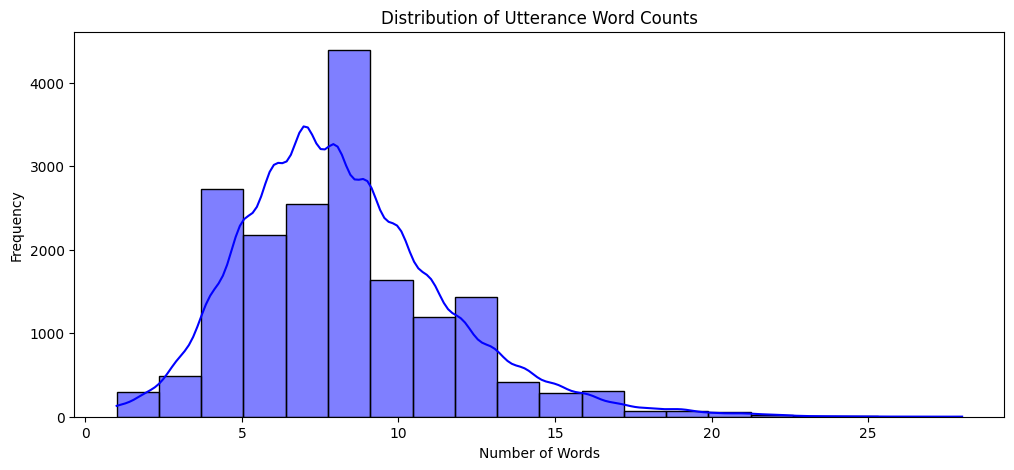

In [185]:
plt.figure(figsize=(12, 5))
sns.histplot(df2['word_count'], bins=20, kde=True, color='blue')
plt.title('Distribution of Utterance Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

## analyzing data_small

In [186]:
with open("F:/MyProjects/Zero-shot-Dynamic-Routing-System/data/data_small.json") as f:
    data_small = json.load(f)

In [187]:
data_small

{'oos_val': [['set a warning for when my bank account starts running low',
   'oos'],
  ['a show on broadway', 'oos'],
  ['who has the best record in the nfl', 'oos'],
  ['how do i find the area of a circle', 'oos'],
  ['how many onions do i have on hand', 'oos'],
  ['what is the name of the 13th president', 'oos'],
  ['show me recent activity in my backyard', 'oos'],
  ['how long will it take me to pay off my card if i pay an extra $50 a month over the minimum',
   'oos'],
  ['does our bank have free notary', 'oos'],
  ['what were the top stories this week', 'oos'],
  ['can i mix antifreeze with water', 'oos'],
  ['are any earning reports due', 'oos'],
  ['show me the channel guide', 'oos'],
  ['is the pnc bank open', 'oos'],
  ['where does the power steering fluid go', 'oos'],
  ['when was the last time the president visited floridau', 'oos'],
  ['how can i keep my windshield from fogging up in winter', 'oos'],
  ['how do i compute the median of a set of numbers', 'oos'],
  ['what is

In [188]:
df_train = pd.DataFrame(data_small['train'], columns=['utterance', 'intent'])
df_test = pd.DataFrame(data_small['test'], columns=['utterance', 'intent'])
df_val = pd.DataFrame(data_small['val'], columns=['utterance', 'intent'])
df_oos = pd.DataFrame(data_small['oos_val'], columns=['utterance', 'intent'])

In [189]:
df3 = pd.concat([df_train,df_test,df_val, df_oos], ignore_index=True)

In [190]:
display(df3.shape)
df3.head()

(15100, 2)

,utterance,intent
0,can you walk me through setting up direct depo...,direct_deposit
1,i want to switch to direct deposit,direct_deposit
2,set up direct deposit for me,direct_deposit
3,how do i go about setting up direct deposit,direct_deposit
4,i need to get my paycheck direct deposited to ...,direct_deposit


In [191]:
print(f"Total In-Scope training Samples: {len(df_train)}")
print(f"Total In-Scope test Samples: {len(df_test)}")
print(f"Total In-Scope Validation Samples: {len(df_val)}")
print(f"Total Out-of-Scope Validation Samples: {len(df_oos)}")
print(f"Total Combined Samples: {len(df3)}")
print(f"Number of Unique In-Scope Intents: {df_train['intent'].nunique()}\n")

Total In-Scope training Samples: 7500
Total In-Scope test Samples: 4500
Total In-Scope Validation Samples: 3000
Total Out-of-Scope Validation Samples: 100
Total Combined Samples: 15100
Number of Unique In-Scope Intents: 150



In [192]:

print(df_train['intent'].value_counts().head(10))

intent
direct_deposit            50
carry_on                  50
whisper_mode              50
text                      50
recipe                    50
smart_home                50
who_do_you_work_for       50
rewards_balance           50
restaurant_reservation    50
travel_notification       50
Name: count, dtype: int64


In [194]:
df3['word_count'] = df3['utterance'].apply(lambda x: len(x.split()))

In [195]:
print(df3['word_count'].describe())

count    15100.000000
mean         8.284172
std          3.255522
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         28.000000
Name: word_count, dtype: float64


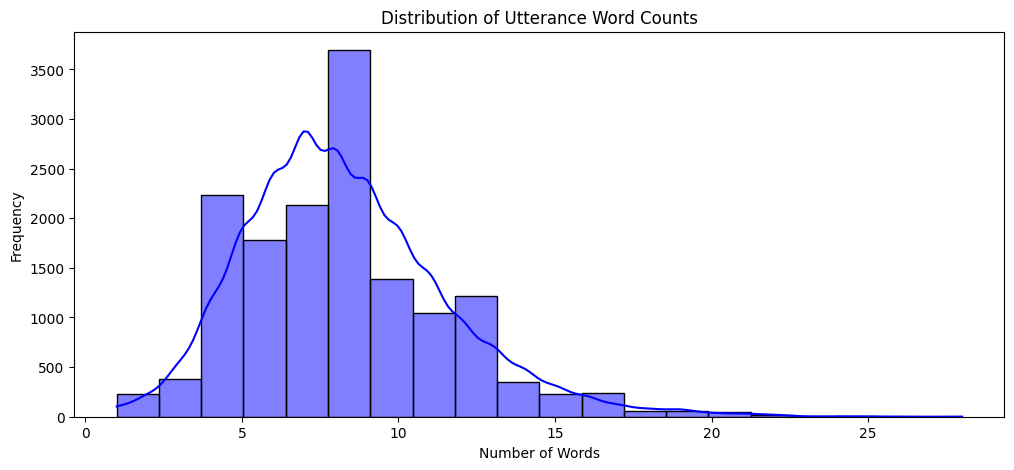

In [196]:
plt.figure(figsize=(12, 5))
sns.histplot(df3['word_count'], bins=20, kde=True, color='blue')
plt.title('Distribution of Utterance Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()